# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_investing_csv(filepath, value_col_name):
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    df[value_col_name] = df["Price"].astype(str).str.replace(",", "").astype(float)
    df = df[["Date", value_col_name]].sort_values(by="Date").reset_index(drop=True)
    return df

bist = load_investing_csv('../data/BIST 100 Historical Data.csv', 'BIST100')
btc = load_investing_csv('../data/Bitcoin Historical Data.csv', 'Bitcoin')
gold = load_investing_csv('../data/Gold Futures Historical Data.csv', 'Gold')
usdtry = load_investing_csv('../data/USD_TRY Historical Data.csv', 'USDTRY')

print(bist.shape, btc.shape, gold.shape, usdtry.shape)
bist.head()


(165, 2) (244, 2) (175, 2) (174, 2)


,Date,BIST100
0,2026-01-02,11498.38
1,2026-01-05,11702.00
2,2026-01-06,12023.78
3,2026-01-07,12028.84
4,2026-01-08,12087.97


In [3]:
df = bist.merge(btc, on='Date', how='inner') \
         .merge(gold, on='Date', how='inner') \
         .merge(usdtry, on='Date', how='inner')

print(df.shape)
df.head()

(164, 5)


,Date,BIST100,Bitcoin,Gold,USDTRY
0,2026-01-02,11498.38,89982.7,4329.6,43.0291
1,2026-01-05,11702.00,93862.2,4451.5,43.0353
2,2026-01-06,12023.78,93739.3,4496.1,43.0310
3,2026-01-07,12028.84,91342.6,4462.5,43.0350
4,2026-01-08,12087.97,91081.7,4460.7,43.0396


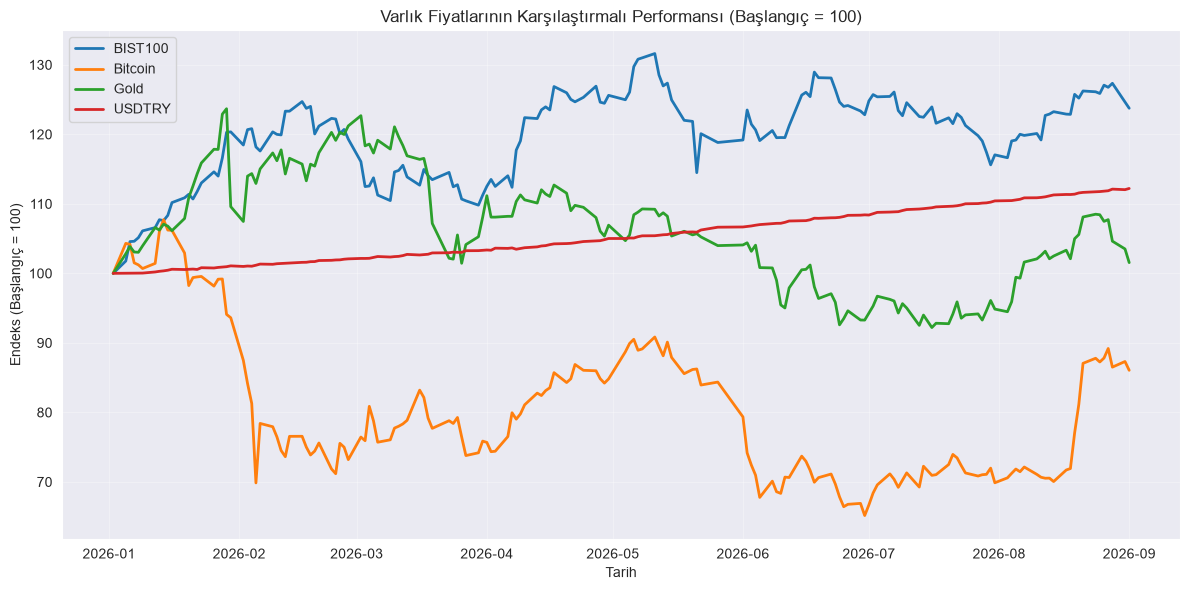

In [7]:
assets = ["BIST100", "Bitcoin", "Gold", "USDTRY"]

normalized = df[assets] / df[assets].iloc[0] * 100

#normalized.head()

plt.figure(figsize = (12,6))
for col in assets:
    plt.plot(df["Date"], normalized[col], label=col, linewidth=2)

plt.legend()
plt.title('Varlık Fiyatlarının Karşılaştırmalı Performansı (Başlangıç = 100)')
plt.xlabel('Tarih')
plt.ylabel('Endeks (Başlangıç = 100)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/fiyat_trendleri.png', dpi=150)
plt.show()

          BIST100   Bitcoin      Gold    USDTRY
BIST100  1.000000  0.074100  0.276872  0.021639
Bitcoin  0.074100  1.000000  0.228817 -0.034342
Gold     0.276872  0.228817  1.000000 -0.035158
USDTRY   0.021639 -0.034342 -0.035158  1.000000


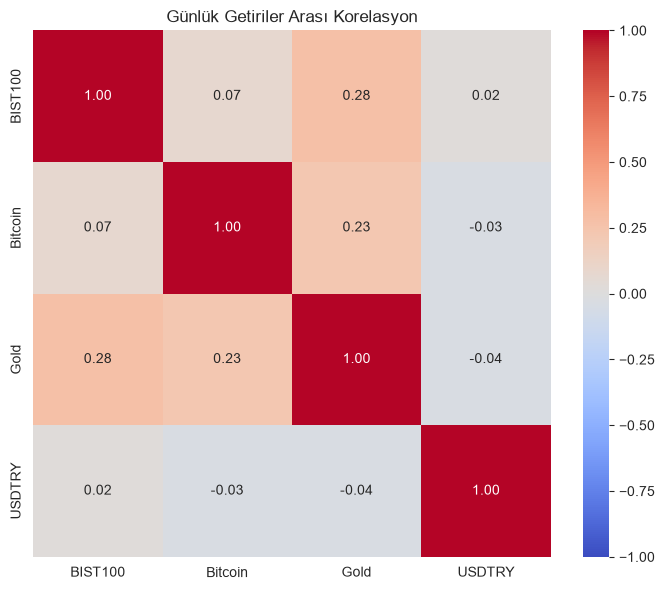

In [10]:
returns = df[assets].pct_change().dropna()
corr = returns.corr()
print(corr)

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Günlük Getiriler Arası Korelasyon')
plt.tight_layout()
plt.savefig('../outputs/korelasyon_heatmap.png', dpi=150)
plt.show()